In [1]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-06 11:09:50.920133: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-06 11:09:50.920506: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fro

In [ ]:
adata = sc.read("E4S_cluster_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 6319 × 2499
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden', 'Macrophage_score', 'T_cell_score', 'Neutrophil_score', 'Dendritic_cell_score', 'Monocyte_score', 'B_cell_score', 'cell_type', 'leiden_R', 'cluster_annotation', 'cnv_leiden', 'cnv_score', 'cnv_status'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'chromosome', 'start', 'end'
    uns: 'cell_type_colors', 'cluster_annotation_colors', 'cnv', 'cnv_leiden', 'cnv_leiden_colors', 'cnv_neighbors', 'cnv_status_colors', 'hvg', 'leiden', 'leiden_R', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'scrublet', 'umap'
    obsm: 'X_cnv', 'X_cnv_pca', 'X_cnv_umap', 'X_pca', 'X_umap'
    varm: 'PCs'

In [4]:
import liana as li
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [6]:
li.rs.show_resources()

['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

In [33]:
li.mt.rank_aggregate(
    adata,
    groupby='cluster_annotation',
    resource_name='mouseconsensus',
    use_raw=False,
    expr_prop=0.001  # lower threshold, default is 0.1
)

In [34]:
adata.obs['cluster_annotation'].value_counts()

cluster_annotation
M1 Mac               1148
Macrophage            859
N1                    845
N2                    817
M2 Mac                475
DC                    441
Monocyte              380
Epithelial            376
Neutrophil            223
Treg                  202
CD8+ T                168
mDC                    98
Malign Epithelial      93
CD4+ T                 78
B                      46
pDC                    42
imflam Mac             28
Name: count, dtype: int64

In [35]:
print(adata.uns['liana_res']['source'].unique())
print(adata.uns['liana_res']['target'].unique())

['N1' 'Neutrophil' 'N2' 'CD8+ T' 'DC' 'Monocyte' 'M1 Mac' 'Epithelial'
 'mDC' 'Macrophage' 'imflam Mac' 'Malign Epithelial' 'Treg' 'M2 Mac' 'B'
 'pDC' 'CD4+ T']
['N1' 'N2' 'imflam Mac' 'Neutrophil' 'mDC' 'Treg' 'M2 Mac' 'CD4+ T' 'pDC'
 'B' 'CD8+ T' 'Monocyte' 'Macrophage' 'M1 Mac' 'Epithelial' 'DC'
 'Malign Epithelial']


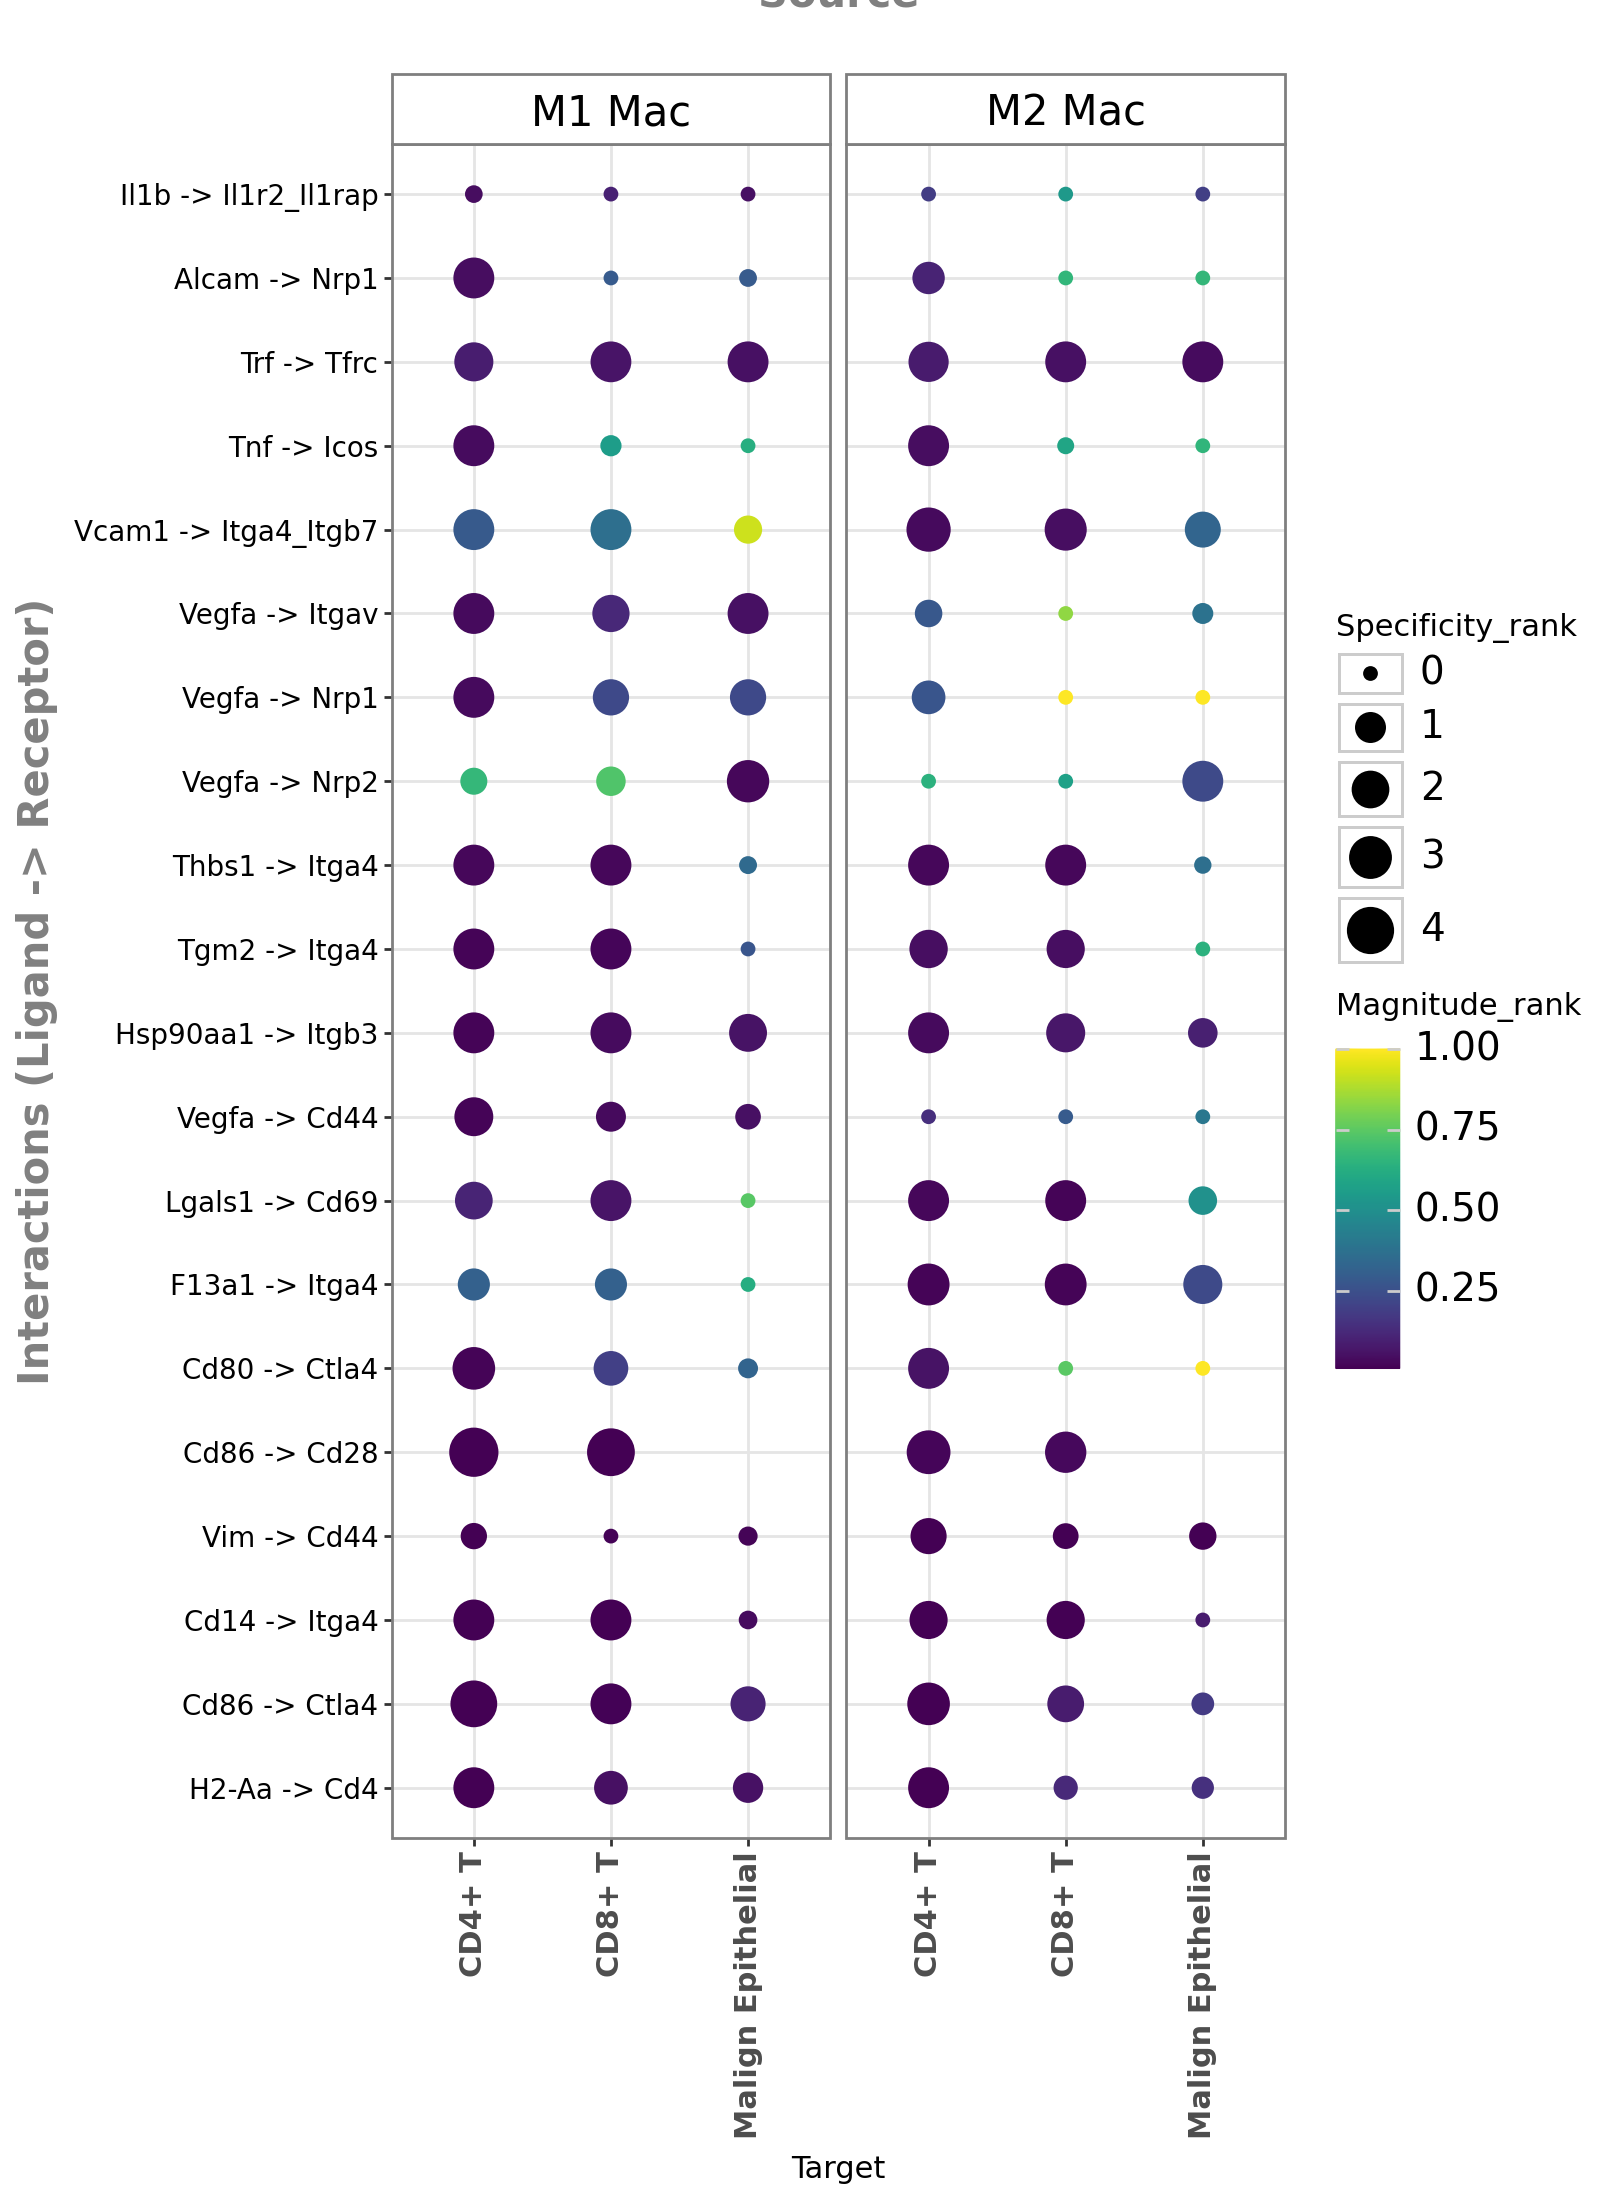

In [39]:
li.pl.dotplot(
    adata,
    colour='magnitude_rank',
    size='specificity_rank',
    source_labels=['M1 Mac', 'M2 Mac'],
    target_labels=['Malign Epithelial', 'CD4+ T', 'CD8+ T'],
    inverse_size=True,
    top_n=20,
    orderby='magnitude_rank',
    orderby_ascending=True,
    figure_size=(8, 11)
)

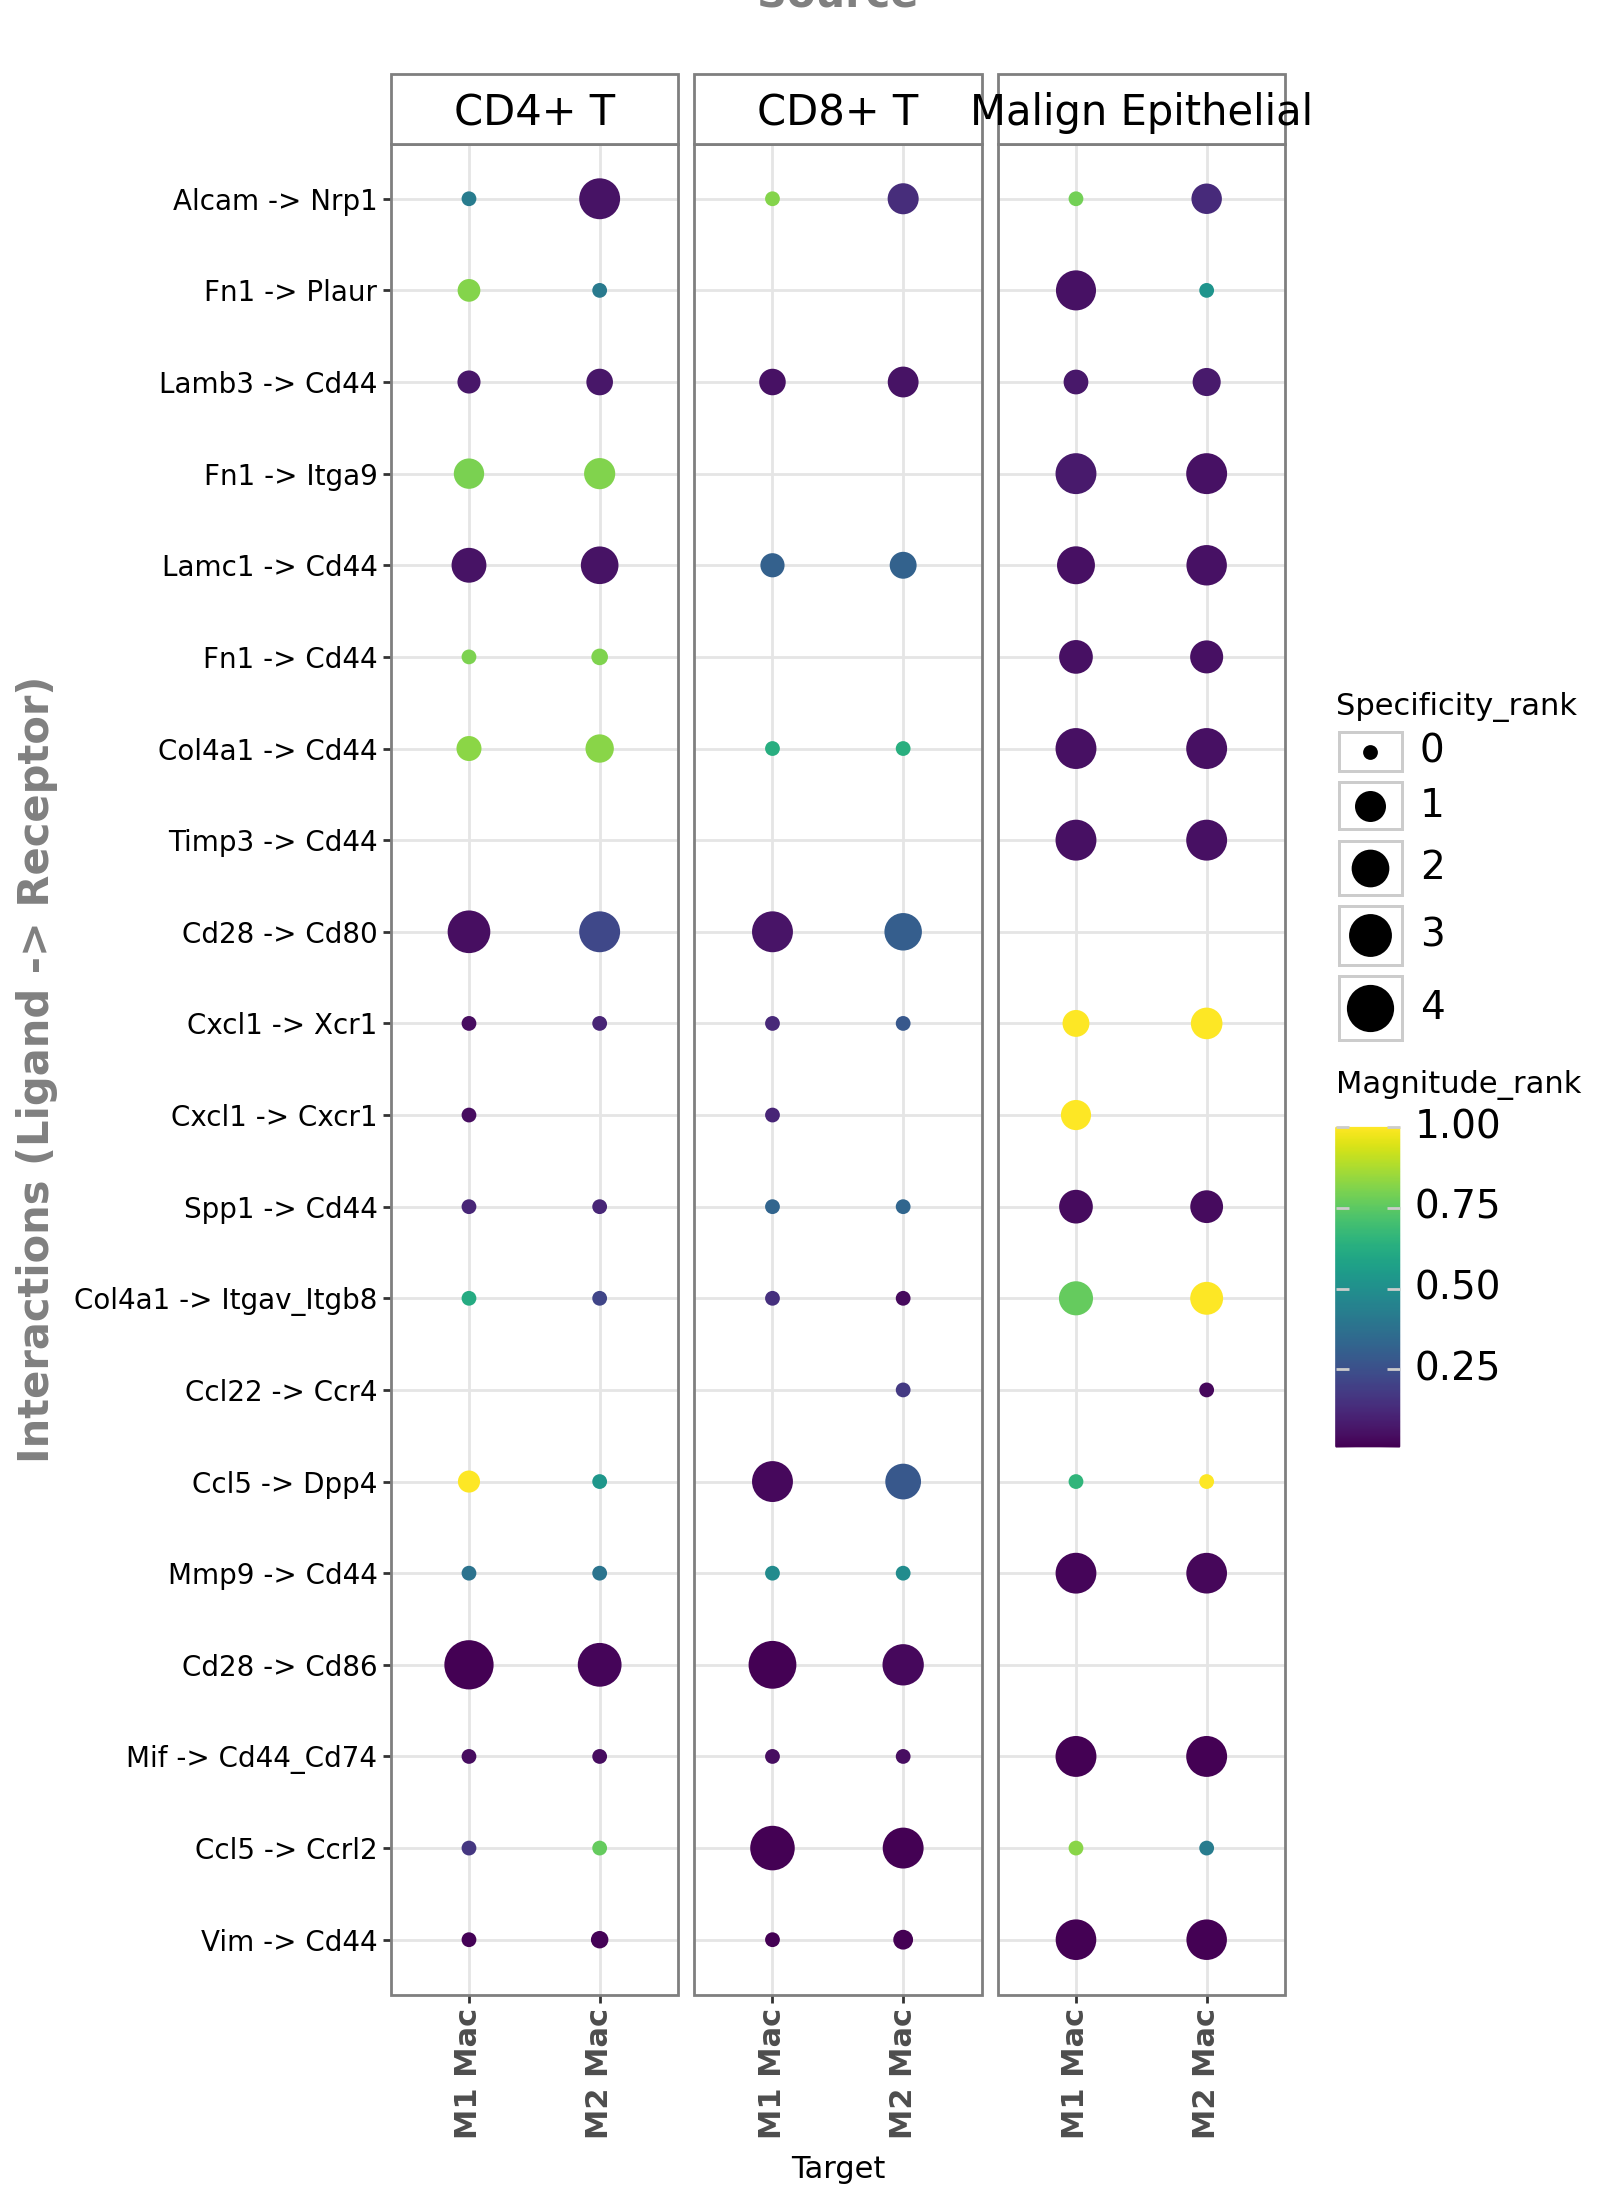

In [40]:
li.pl.dotplot(
    adata,
    colour='magnitude_rank',
    size='specificity_rank',
    source_labels=['Malign Epithelial', 'CD4+ T', 'CD8+ T'],
    target_labels=['M1 Mac', 'M2 Mac'],
    inverse_size=True,
    top_n=20,
    orderby='magnitude_rank',
    orderby_ascending=True,
    figure_size=(8, 11)
)

# DEA

### This check Differential expression between conditions (usually different samples)

In [ ]:
# adata.obs['sample_id'] = 'E4S'
adata

AnnData object with n_obs × n_vars = 6319 × 2499
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden', 'Macrophage_score', 'T_cell_score', 'Neutrophil_score', 'Dendritic_cell_score', 'Monocyte_score', 'B_cell_score', 'cell_type', 'leiden_R', 'cluster_annotation', 'cnv_leiden', 'cnv_score', 'cnv_status', 'sample_id'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'chromosome', 'start', 'end'
    uns: 'cell_type_colors', 'cluster_annotation_colors', 'cnv', 'cnv_leiden', 'cnv_leiden_colors', 'cnv_neighbors', 'cnv_status_colors', 'hvg', 'leiden', 'leiden_R', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'scrublet', 'umap', 'cpdb_res', 'liana_res'
    obsm: 'X_cnv', 'X_cnv_pca', 'X_cnv_um

In [ ]:
pdata = dc.pp.pseudobulk(
    adata,
    sample_col='sample_id',
    groups_col='cluster_annotation',
    layer='counts',
    mode='sum'
)
pdata

KeyError: 'counts'

In [ ]:
import omnipath as op
import plotnine as p9
import decoupler as dc

#  dea_df should have genes ranked by how differentially expressed 
#  they are between conditions within each cluster

In [54]:
# Run rank_genes_groups for each leiden cluster
sc.tl.rank_genes_groups(adata, 'cluster_annotation', method='wilcoxon')

# Extract top 20 genes per cluster into a DataFrame
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
n_genes = 20

df_top_genes = pd.DataFrame({
    group: result['names'][group][:n_genes] for group in groups
})

# Also create a version with scores and pvals
df_detailed = pd.DataFrame()
for group in groups:
    temp_df = pd.DataFrame({
        'cluster_annotation': group,
        'gene': result['names'][group][:n_genes],
        'scores': result['scores'][group][:n_genes],
        'logfoldchanges': result['logfoldchanges'][group][:n_genes],
        'pvals': result['pvals'][group][:n_genes],
        'pvals_adj': result['pvals_adj'][group][:n_genes],
    })
    df_detailed = pd.concat([df_detailed, temp_df], ignore_index=True)

# Filter df_detailed so it only contains genes present in adata.var_names
df_detailed = df_detailed[df_detailed['gene'].isin(adata.var_names)].copy()
# Set the index to 'gene'
df_detailed.set_index('gene', inplace=True)

In [73]:
df_detailed

,cluster_annotation,scores,logfoldchanges,pvals,pvals_adj
Mef2c,B,11.193429,4.510068,4.391180e-29,1.097356e-25
Ighm,B,10.995177,5.843260,4.031212e-28,5.037000e-25
Cd79a,B,10.929148,11.055655,8.363053e-28,5.400480e-25
Ebf1,B,10.926146,11.449538,8.644226e-28,5.400480e-25
Bank1,B,10.626254,8.919856,2.249683e-26,1.124391e-23
...,...,...,...,...,...
Pacsin1,pDC,10.567287,7.486852,4.225407e-26,6.599558e-24
Plac8,pDC,10.533341,5.196239,6.064312e-26,8.914538e-24
Blnk,pDC,10.515434,4.594847,7.334207e-26,1.018232e-23
Rnase6,pDC,10.500243,5.841221,8.615766e-26,1.133200e-23


In [ ]:
groupby = 'cluster_annotation'
lr_res = li.multi.df_to_lr(adata,
                           dea_df= df_detailed,
                           resource_name='mouseconsensus', # NOTE: uses HUMAN gene symbols!
                           expr_prop=0.01, # calculated for adata as passed - used to filter interactions
                           groupby=groupby,
                           stat_keys=['scores', 'pvals', 'pvals_adj'],
                           use_raw=False,
                           complex_col='scores', # NOTE: we use the Wald Stat to deal with complexes
                           verbose=True,
                           return_all_lrs=False,
                           )

Using resource `mouseconsensus`.
Using `.X`!
0.96 of entities in the resource are missing from the data.


In [59]:
lr_res.head()

,ligand,receptor,ligand_complex,receptor_complex,source,ligand_scores,ligand_pvals,ligand_pvals_adj,ligand_expr,ligand_props,...,receptor_pvals,receptor_pvals_adj,receptor_expr,receptor_props,interaction_scores,interaction_pvals,interaction_pvals_adj,interaction_expr,interaction_props,interaction
0,Ccl5,Dpp4,Ccl5,Dpp4,CD8+ T,17.719219,2.980192e-70,4.964999e-68,2.555237,0.851190,...,8.579594e-139,7.146802e-136,1.173912,0.843085,21.398760,1.490096e-70,2.482500e-68,1.864574,0.847138,Ccl5^Dpp4
1,Ccl5,Ccrl2,Ccl5,Ccrl2,CD8+ T,17.719219,2.980192e-70,4.964999e-68,2.555237,0.851190,...,2.208997e-167,5.018439e-165,2.648385,0.921665,22.647198,1.490096e-70,2.482500e-68,2.601811,0.886428,Ccl5^Ccrl2
2,Ccl5,Ccrl2,Ccl5,Ccrl2,CD8+ T,17.719219,2.980192e-70,4.964999e-68,2.555237,0.851190,...,6.631343e-36,5.178665e-34,2.687812,0.825112,15.114315,3.315672e-36,2.589332e-34,2.621525,0.838151,Ccl5^Ccrl2
3,Vegfa,Itga9,Vegfa,Itga9,M1 Mac,29.028046,2.913228e-185,4.550098e-183,1.214644,0.833624,...,5.514395e-226,2.296745e-223,1.373619,0.907666,30.560541,1.456614e-185,2.275049e-183,1.294132,0.870645,Vegfa^Itga9
4,Vegfa,Nrp1,Vegfa,Nrp1,M1 Mac,29.028046,2.913228e-185,4.550098e-183,1.214644,0.833624,...,5.429649e-143,9.691924e-141,1.387071,0.871579,27.244171,2.714825e-143,4.845962e-141,1.300858,0.852601,Vegfa^Nrp1


In [60]:
lr_res = lr_res.sort_values("interaction_scores", ascending=False, key=abs)
lr_res.head()

,ligand,receptor,ligand_complex,receptor_complex,source,ligand_scores,ligand_pvals,ligand_pvals_adj,ligand_expr,ligand_props,...,receptor_pvals,receptor_pvals_adj,receptor_expr,receptor_props,interaction_scores,interaction_pvals,interaction_pvals_adj,interaction_expr,interaction_props,interaction
17,Cxcl2,Cxcr2,Cxcl2,Cxcr2,N1,39.597179,0.000000e+00,0.000000e+00,5.048503,0.968047,...,8.883774e-300,1.480037e-297,2.183151,0.893491,38.302017,4.441887e-300,7.400184e-298,3.615828,0.930769,Cxcl2^Cxcr2
18,Cxcl2,Cxcr2,Cxcl2,Cxcr2,N1,39.597179,0.000000e+00,0.000000e+00,5.048503,0.968047,...,1.661771e-134,1.431989e-132,1.504029,0.752754,32.139679,8.308857e-135,7.159943e-133,3.276266,0.860401,Cxcl2^Cxcr2
6,Cd86,Ctla4,Cd86,Ctla4,M1 Mac,38.866558,0.000000e+00,0.000000e+00,2.319184,0.993031,...,2.891043e-115,2.408239e-112,2.645411,0.960396,30.843369,1.445521e-115,1.204119e-112,2.482297,0.976714,Cd86^Ctla4
3,Vegfa,Itga9,Vegfa,Itga9,M1 Mac,29.028046,2.913228e-185,4.550098e-183,1.214644,0.833624,...,5.514395e-226,2.296745e-223,1.373619,0.907666,30.560541,1.456614e-185,2.275049e-183,1.294132,0.870645,Vegfa^Itga9
5,Vegfa,Itga9,Vegfa,Itga9,M1 Mac,29.028046,2.913228e-185,4.550098e-183,1.214644,0.833624,...,2.420257e-176,1.512056e-173,1.426696,0.919674,28.670307,1.210129e-176,7.560278e-174,1.320670,0.876649,Vegfa^Itga9


In [ ]:
# Let's visualize how this looks like for all interactions  (across all cell types)
lr_res = lr_res.sort_values("interaction_scores", ascending=False)

<Axes: >

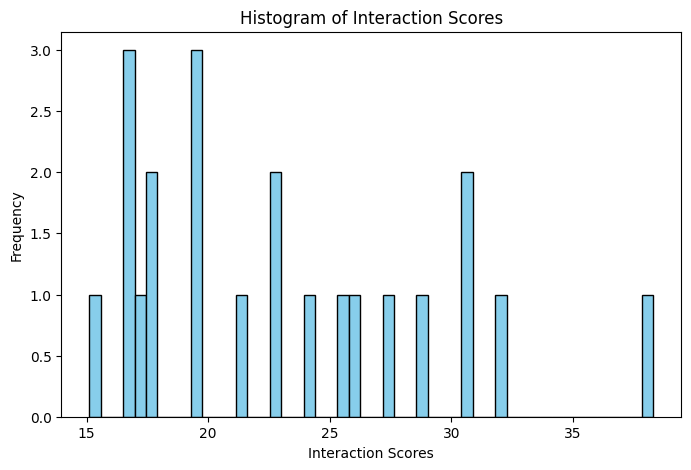

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(lr_res['interaction_scores'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Interaction Scores')
plt.ylabel('Frequency')
plt.title('Histogram of Interaction Scores')
plt.show()

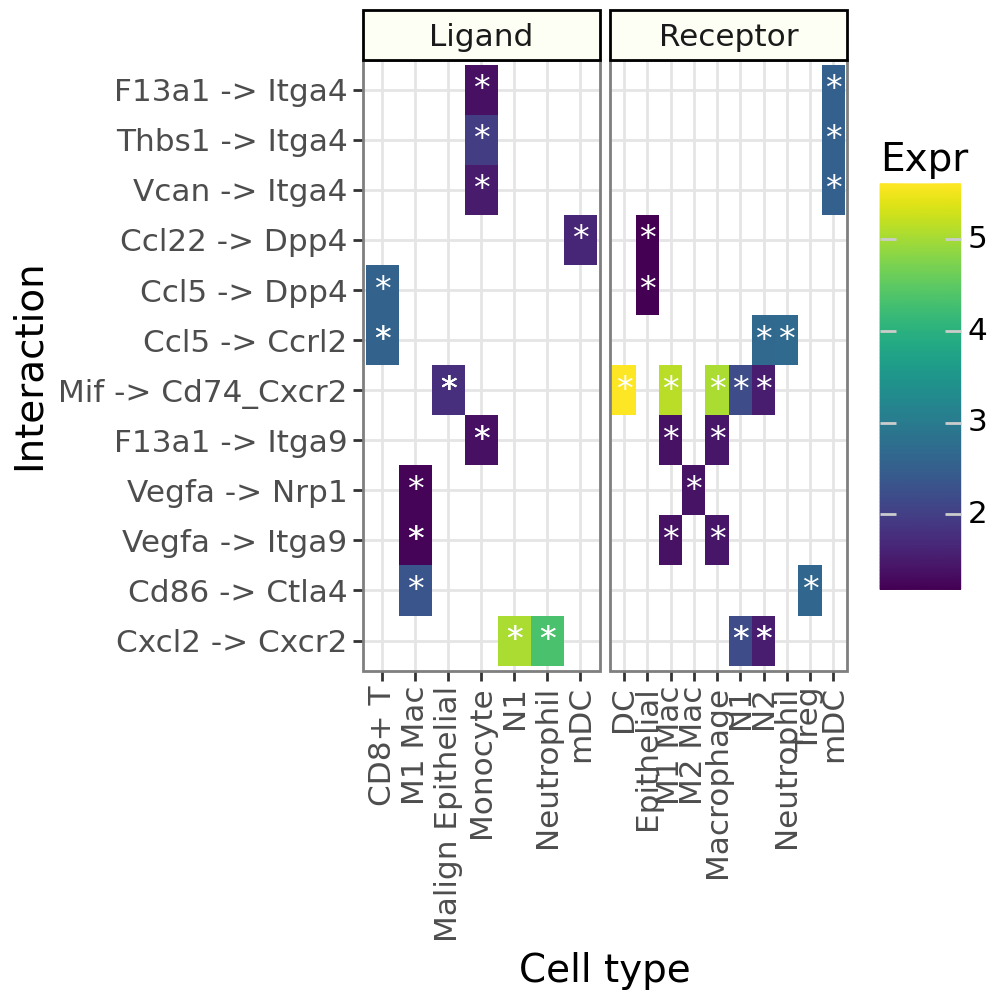

In [ ]:
li.pl.tileplot(liana_res=lr_res,
               fill = 'expr',
               label='pvals_adj',
               label_fun = lambda x: '*' if x < 0.05 else np.nan,
               top_n=15,
               orderby = 'interaction_scores',
               orderby_ascending = False,
               orderby_absolute = False,
               source_title='Ligand',
               target_title='Receptor',
               )

In [81]:
print(lr_res['source'].unique())
print(lr_res['target'].unique())

['N1' 'M1 Mac' 'Monocyte' 'Neutrophil' 'Malign Epithelial' 'CD8+ T' 'mDC']
['N1' 'N2' 'Treg' 'M1 Mac' 'Macrophage' 'M2 Mac' 'Epithelial' 'mDC' 'DC'
 'Neutrophil']


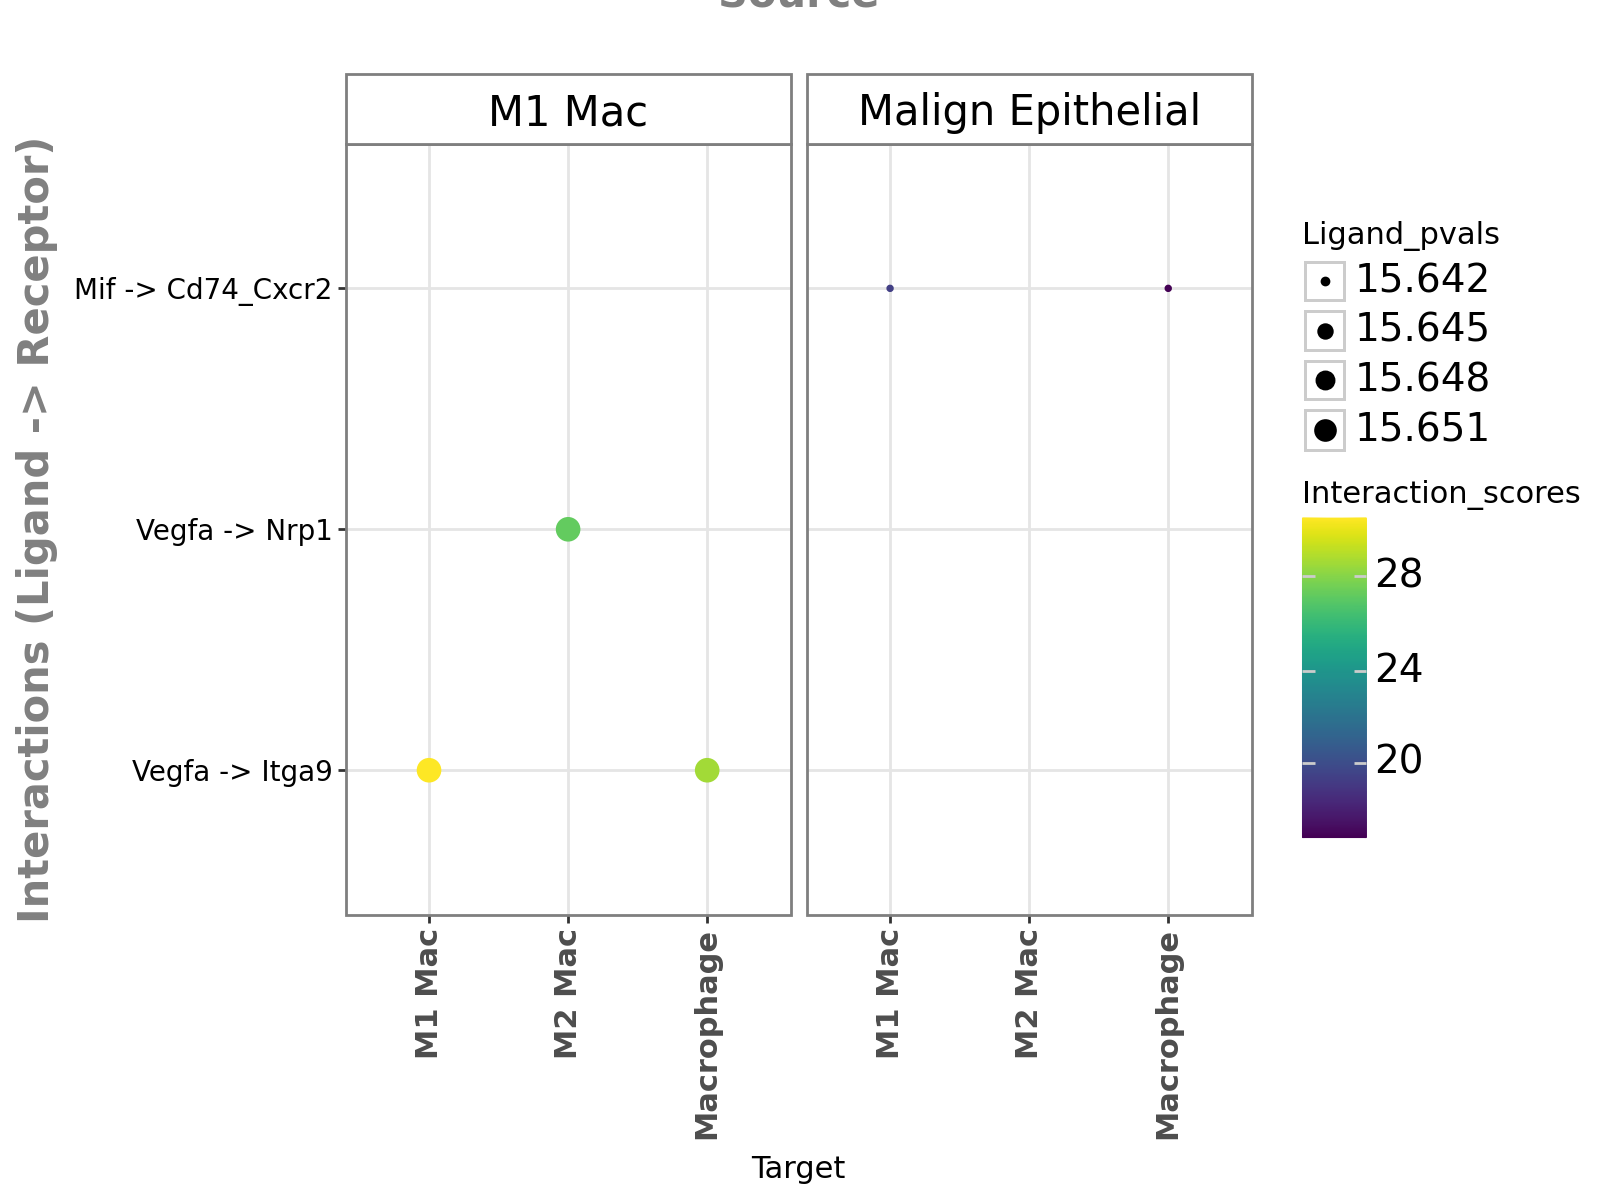

In [86]:
plot = li.pl.dotplot(liana_res=lr_res,
                     colour='interaction_scores',
                     size='ligand_pvals',
                     inverse_size=True,
                     orderby='interaction_scores',
                     orderby_ascending=False,
                     orderby_absolute=True,
                     source_labels=['Malign Epithelial','Neutrophil','M1 Mac'],
                     target_labels=['M1 Mac', 'Macrophage', 'M2 Mac'],
                     top_n=15,
                     size_range=(0.5, 4)
                     )
plot.show()

# DEA correct